<a href="https://colab.research.google.com/github/shivanshi-09/Introduction-to-Machine-Learning-/blob/main/A2Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import time
import numpy as np

In [2]:
transform = transforms.ToTensor()
full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
testset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

n = len(full)
trainset, valset = random_split(full, [int(0.85*n), n - int(0.85*n)])
trainloader = DataLoader(trainset, batch_size=256, shuffle=True)
valloader = DataLoader(valset, batch_size=256)

class AE(nn.Module):
    def __init__(self, dims):
        super().__init__()
        enc = []
        for i in range(len(dims)-1):
            enc += [nn.Linear(dims[i], dims[i+1]), nn.ReLU()]
        self.enc = nn.Sequential(*enc)
        dec = []
        rdims = dims[::-1]
        for i in range(len(rdims)-1):
            dec += [nn.Linear(rdims[i], rdims[i+1])]
            if i < len(rdims)-2:
                dec += [nn.ReLU()]
        dec += [nn.Sigmoid()]
        self.dec = nn.Sequential(*dec)

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z)

configs = {
    'tiny': [784, 128, 32],
    'small': [784, 256, 64, 16],
    'medium':[784, 512, 128, 32],
    'large': [784, 512, 256, 64, 16],
    'xlarge':[784, 1024, 512, 128, 32],}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loss_fn = nn.MSELoss()
records = {}

for name, dims in configs.items():
    model = AE(dims).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    tlosses, vlosses = [], []
    t0 = time.time()
    for epoch in range(15):
        model.train()
        batch_losses = []
        for imgs, _ in trainloader:
            imgs = imgs.view(imgs.size(0), -1).to(device)
            out = model(imgs)
            loss = loss_fn(out, imgs)
            opt.zero_grad(); loss.backward(); opt.step()
            batch_losses.append(loss.item())
        tlosses.append(np.mean(batch_losses))
        model.eval()
        vb = []
        with torch.no_grad():
            for imgs, _ in valloader:
                imgs = imgs.view(imgs.size(0), -1).to(device)
                vb.append(loss_fn(model(imgs), imgs).item())
        vlosses.append(np.mean(vb))

    elapsed = time.time() - t0
    records[name] = dict(train=tlosses, val=vlosses, secs=elapsed, model=model, dims=dims)
    print(f"{name:8s}  {elapsed:.1f}s  final val={vlosses[-1]:.4f}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.33MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.1MB/s]


tiny      99.2s  final val=0.0136
small     98.9s  final val=0.0160
medium    99.3s  final val=0.0120
large     99.8s  final val=0.0145
xlarge    102.4s  final val=0.0120


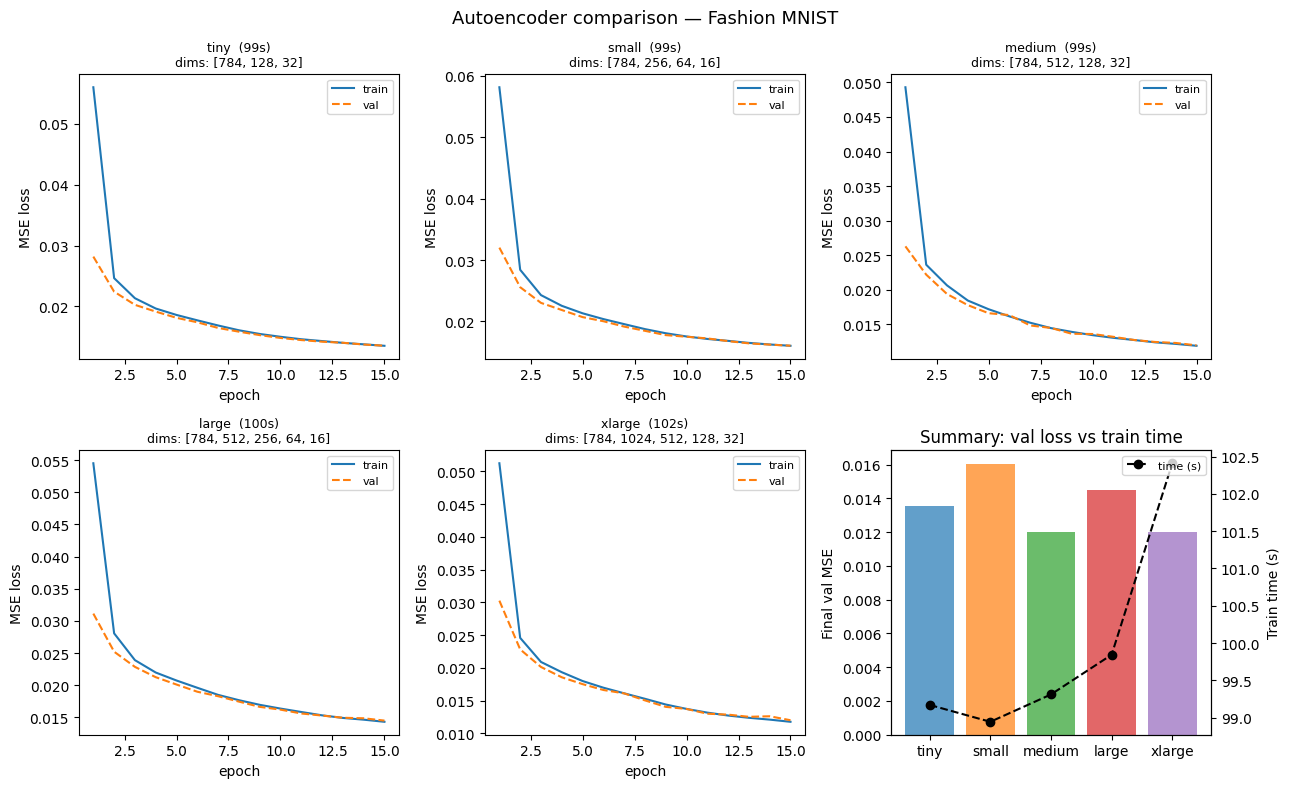

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle('Autoencoder comparison — Fashion MNIST', fontsize=13)
axes = axes.flatten()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for ax, (name, rec) in zip(axes[:5], records.items()):
    epochs = range(1, 16)
    ax.plot(epochs, rec['train'], label='train')
    ax.plot(epochs, rec['val'],   label='val', linestyle='--')
    ax.set_title(f"{name}  ({rec['secs']:.0f}s)\ndims: {rec['dims']}", fontsize=9)
    ax.set_xlabel('epoch')
    ax.set_ylabel('MSE loss')
    ax.legend(fontsize=8)

ax = axes[5]
names  = list(records.keys())
finals = [records[n]['val'][-1] for n in names]
times  = [records[n]['secs']    for n in names]

ax2 = ax.twinx()
bars = ax.bar(names, finals, color=colors[:5], alpha=0.7)
ax2.plot(names, times, 'o--', color='black', label='time (s)')
ax.set_ylabel('Final val MSE')
ax2.set_ylabel('Train time (s)')
ax.set_title('Summary: val loss vs train time')
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

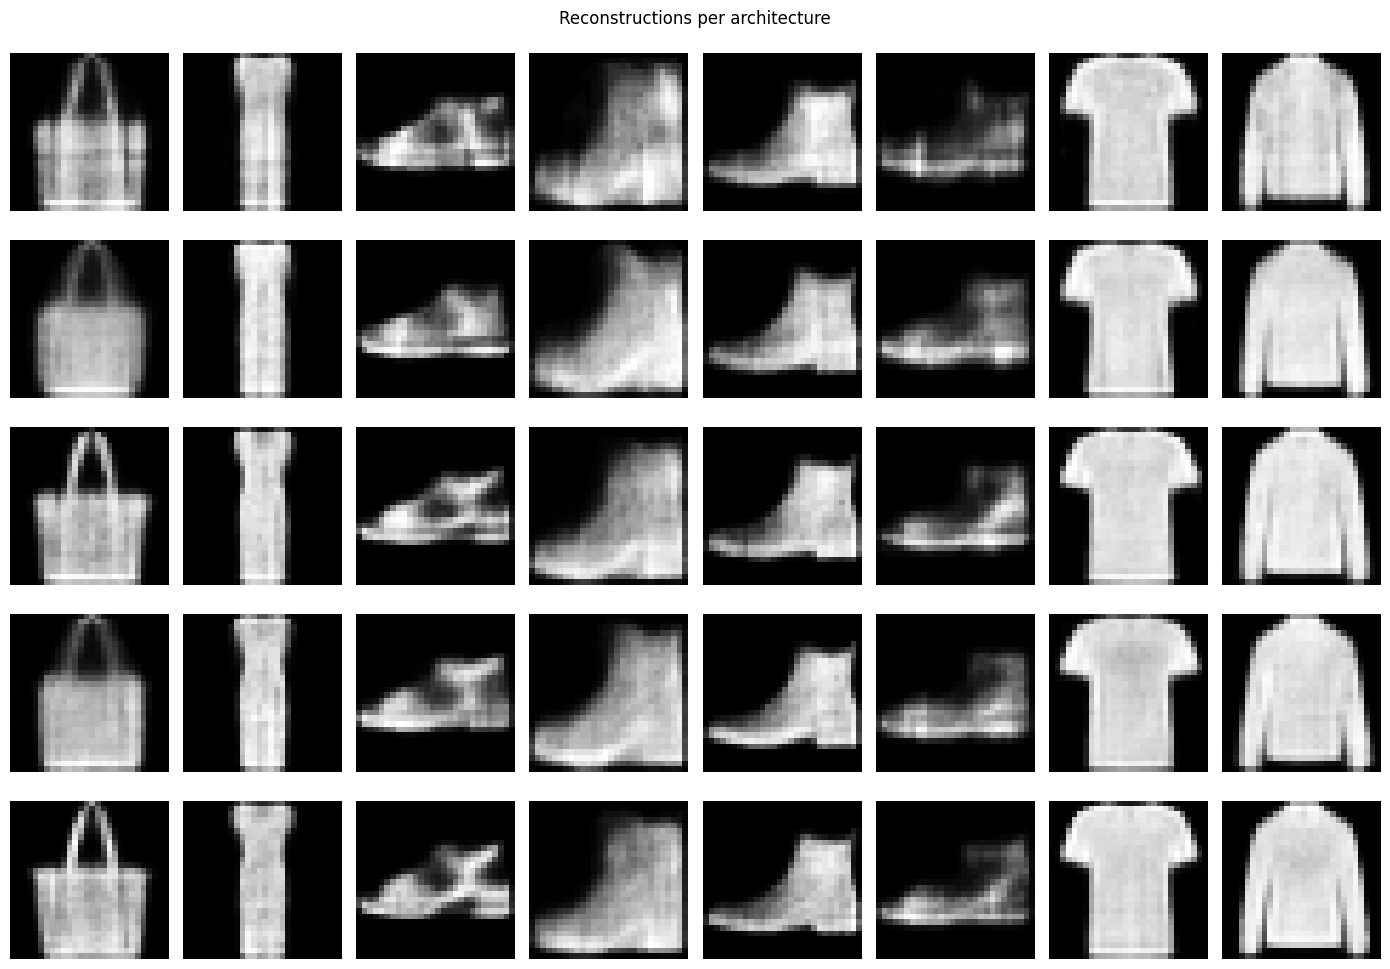

In [4]:
fig, axes = plt.subplots(len(configs), 8, figsize=(14, 10))
fig.suptitle('Reconstructions per architecture', fontsize=12)

testloader = DataLoader(testset, batch_size=8, shuffle=True)
sample, _ = next(iter(testloader))
sample_flat = sample.view(8, -1).to(device)

for row, (name, rec) in enumerate(records.items()):
    rec['model'].eval()
    with torch.no_grad():
        recon = rec['model'](sample_flat).cpu().view(8, 28, 28)
    for col in range(8):
        ax = axes[row][col]
        ax.imshow(recon[col].numpy(), cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(name, fontsize=8)

plt.tight_layout()
plt.show()